# **Ford GoBike (Bay Area Bike Share) — Exploratory Data Analysis**

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** Sree Akanksha Munduri

# **Project Summary -**

This project performs an end-to-end Exploratory Data Analysis (EDA) on Ford GoBike trip data for the San Francisco Bay Area, covering all 12 months of 2018 (January–December), totaling over 1.86 million individual bike trips.

The raw data is spread across 12 monthly CSV files, each recording trip-level details: trip duration, start/end time, start/end station (with GPS coordinates), bike ID, user type (Subscriber vs. Customer), and rider demographics (birth year, gender) where available.

The goal of this analysis is to understand how, when, and by whom the bike-share system is used, in order to generate insights that Ford GoBike's operations, marketing, and station-planning teams can act on. The analysis is organized into three levels of investigation: **univariate** analysis (examining single variables like trip duration, user type, and rider age in isolation), **bivariate** analysis (examining relationships between two variables, such as duration vs. user type, or trip volume vs. hour of day), and **multivariate** analysis (examining interactions among three or more variables at once, such as how usage patterns by hour differ between user types and days of the week).

Data wrangling steps included: combining 12 monthly files into a single dataset, converting timestamps to proper datetime objects, deriving trip duration in minutes, extracting hour/day-of-week/month features, computing rider age from birth year, removing implausible outliers (trips longer than 24 hours, riders below 18 or above 80 years old), and handling missing demographic fields (present mostly for one-time "Customer" users rather than "Subscribers").

Key findings include a strong weekday commuter pattern among Subscribers (sharp peaks at 8 AM and 5–6 PM) contrasted with a leisure-driven, weekend-heavy pattern among Customers; Subscribers take much shorter but far more frequent trips than Customers; ridership is heavily concentrated in a small number of downtown San Francisco stations; and usage rises steadily through the year, peaking during California's dry, temperate mid-to-late summer months. These findings translate into concrete recommendations around bike rebalancing schedules, targeted subscription marketing to frequent weekend Customers, and station capacity planning.

The notebook below walks through the full pipeline — from raw data to cleaned dataset, through 15 visualizations spanning univariate, bivariate, and multivariate analysis, to a final set of business recommendations.

# **GitHub Link -**

_Add your GitHub repository link here once you upload this notebook and the writeup._

# **Problem Statement**

Ford GoBike operates a bike-share system across the San Francisco Bay Area. The company has trip-level usage data but needs to understand rider behavior patterns — when trips happen, how long they last, who is taking them, and where they start/end — to make better decisions on bike rebalancing, station placement, and subscriber growth.

#### **Define Your Business Objective?**

To analyze one full year (2018) of Ford GoBike trip data to uncover usage patterns across time (hour/day/month), rider segments (Subscriber vs. Customer, gender, age), and geography (stations), and to translate these patterns into actionable recommendations for **operations** (bike rebalancing and fleet allocation), **station planning** (where demand is concentrated), and **growth/marketing** (converting frequent Customers into Subscribers).

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [42]:
import glob
files = glob.glob('*fordgobike-tripdata*.zip')
print(len(files), "files found:")
for f in sorted(files):
    print(" ", f)

12 files found:
  201801-fordgobike-tripdata.csv.zip
  201802-fordgobike-tripdata.csv.zip
  201803-fordgobike-tripdata.csv.zip
  201804-fordgobike-tripdata.csv.zip
  201805-fordgobike-tripdata.csv.zip
  201806-fordgobike-tripdata.csv.zip
  201807-fordgobike-tripdata.csv.zip
  201808-fordgobike-tripdata.csv.zip
  201809-fordgobike-tripdata.csv (1).zip
  201810-fordgobike-tripdata.csv.zip
  201811-fordgobike-tripdata.csv.zip
  201812-fordgobike-tripdata.csv.zip


In [43]:
import subprocess
result = subprocess.run(['find', '/content/drive', '-iname', '*fordgobike-tripdata*'], capture_output=True, text=True)
print(result.stdout)

In [44]:
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("Return code:", result.returncode)

STDOUT: 
STDERR: find: ‘/content/drive’: No such file or directory

Return code: 1


In [45]:
# Import Libraries
import pandas as pd
import numpy as np
import zipfile
import glob
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

In [46]:
import glob
files = glob.glob('*fordgobike-tripdata*.zip')
print(len(files), "files found:")
for f in sorted(files):
    print(" ", f)

12 files found:
  201801-fordgobike-tripdata.csv.zip
  201802-fordgobike-tripdata.csv.zip
  201803-fordgobike-tripdata.csv.zip
  201804-fordgobike-tripdata.csv.zip
  201805-fordgobike-tripdata.csv.zip
  201806-fordgobike-tripdata.csv.zip
  201807-fordgobike-tripdata.csv.zip
  201808-fordgobike-tripdata.csv.zip
  201809-fordgobike-tripdata.csv (1).zip
  201810-fordgobike-tripdata.csv.zip
  201811-fordgobike-tripdata.csv.zip
  201812-fordgobike-tripdata.csv.zip


In [47]:
import os
print(os.listdir('.'))

['.config', '201803-fordgobike-tripdata.csv.zip', '201812-fordgobike-tripdata.csv.zip', '201810-fordgobike-tripdata.csv.zip', '201809-fordgobike-tripdata.csv (1).zip', '201808-fordgobike-tripdata.csv.zip', '201801-fordgobike-tripdata.csv.zip', '201807-fordgobike-tripdata.csv.zip', '201805-fordgobike-tripdata.csv.zip', '201806-fordgobike-tripdata.csv.zip', '201804-fordgobike-tripdata.csv.zip', '201802-fordgobike-tripdata.csv.zip', '201811-fordgobike-tripdata.csv.zip', 'sample_data']


### Dataset Loading

In [48]:
# Load Dataset
# All 12 monthly zip files (Jan 2018 - Dec 2018) should be in the same folder as this notebook.
zip_files = sorted(glob.glob('*fordgobike-tripdata*.zip'))
print(f"Found {len(zip_files)} monthly files:")
for f in zip_files:
    print(" ", f)

monthly_frames = []
for f in zip_files:
    with zipfile.ZipFile(f) as z:
        inner_name = [n for n in z.namelist() if n.endswith('.csv')][0]
        with z.open(inner_name) as fh:
            monthly_frames.append(pd.read_csv(fh))

df = pd.concat(monthly_frames, ignore_index=True)
print(f"\nCombined shape: {df.shape}")

Found 12 monthly files:
  201801-fordgobike-tripdata.csv.zip
  201802-fordgobike-tripdata.csv.zip
  201803-fordgobike-tripdata.csv.zip
  201804-fordgobike-tripdata.csv.zip
  201805-fordgobike-tripdata.csv.zip
  201806-fordgobike-tripdata.csv.zip
  201807-fordgobike-tripdata.csv.zip
  201808-fordgobike-tripdata.csv.zip
  201809-fordgobike-tripdata.csv (1).zip
  201810-fordgobike-tripdata.csv.zip
  201811-fordgobike-tripdata.csv.zip
  201812-fordgobike-tripdata.csv.zip

Combined shape: (1863721, 16)


### Dataset First View

In [49]:
# Dataset First Look
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,2018-01-31 22:52:35.2390,2018-02-01 19:47:19.8240,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No
1,85422,2018-01-31 16:13:34.3510,2018-02-01 15:57:17.3100,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No
2,71576,2018-01-31 14:23:55.8890,2018-02-01 10:16:52.1160,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No
3,61076,2018-01-31 14:53:23.5620,2018-02-01 07:51:20.5000,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No
4,39966,2018-01-31 19:52:24.6670,2018-02-01 06:58:31.0530,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No


### Dataset Rows & Columns count

In [50]:
# Dataset Rows & Columns count
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 1,863,721
Columns: 16


### Dataset Information

In [51]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863721 entries, 0 to 1863720
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   duration_sec             int64  
 1   start_time               object 
 2   end_time                 object 
 3   start_station_id         float64
 4   start_station_name       object 
 5   start_station_latitude   float64
 6   start_station_longitude  float64
 7   end_station_id           float64
 8   end_station_name         object 
 9   end_station_latitude     float64
 10  end_station_longitude    float64
 11  bike_id                  int64  
 12  user_type                object 
 13  member_birth_year        float64
 14  member_gender            object 
 15  bike_share_for_all_trip  object 
dtypes: float64(7), int64(2), object(7)
memory usage: 227.5+ MB


#### Duplicate Values

In [52]:
# Dataset Duplicate Value Count
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


#### Missing Values/Null Values

In [53]:
# Missing Values/Null Values Count
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)

,missing_count,missing_pct
member_birth_year,110718,5.94
member_gender,110367,5.92
start_station_id,11771,0.63
start_station_name,11771,0.63
end_station_id,11771,0.63
end_station_name,11771,0.63
end_time,0,0.00
duration_sec,0,0.00
start_station_longitude,0,0.00
start_station_latitude,0,0.00


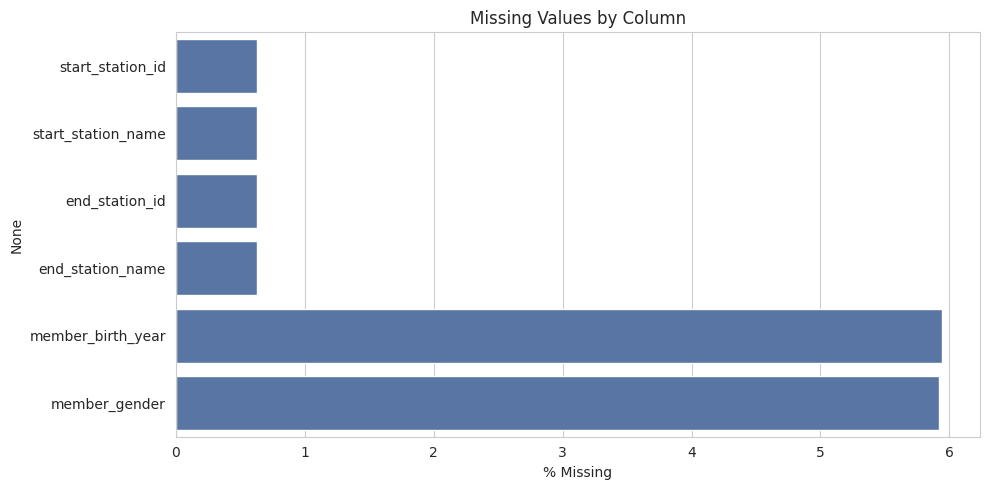

In [54]:
# Visualizing the missing values
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_pct[missing_pct > 0].values, y=missing_pct[missing_pct > 0].index, color='#4C72B0')
plt.xlabel('% Missing')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset contains **1,863,721 trips** across 16 columns spanning January–December 2018. There are no duplicate rows. Missing values are concentrated in three demographic/station columns: `member_birth_year`, `member_gender`, and `bike_share_for_all_trip` — these are missing almost exclusively for **Customer** (one-time/casual) riders, since Ford GoBike only collects demographic profile data from registered **Subscribers**. A small number of station ID/name/lat/long fields are also occasionally missing, likely due to trips that started or ended at "dockless" locations rather than fixed stations. No column is missing more than ~9% of its values.

## ***2. Understanding Your Variables***

In [55]:
# Dataset Columns
df.columns.tolist()

['duration_sec',
 'start_time',
 'end_time',
 'start_station_id',
 'start_station_name',
 'start_station_latitude',
 'start_station_longitude',
 'end_station_id',
 'end_station_name',
 'end_station_latitude',
 'end_station_longitude',
 'bike_id',
 'user_type',
 'member_birth_year',
 'member_gender',
 'bike_share_for_all_trip']

In [56]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
duration_sec,1863721.0,NaN,NaN,NaN,857.302571,2370.378862,61.0,350.0,556.0,872.0,86366.0
start_time,1863721,1863584,2018-12-21 07:34:19.3650,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_time,1863721,1863610,2018-06-10 12:55:58.8970,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_station_id,1851950.0,NaN,NaN,NaN,119.674436,100.397559,3.0,33.0,89.0,186.0,381.0
start_station_name,1851950,348,San Francisco Ferry Building (Harry Bridges Pl...,38461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_station_latitude,1863721.0,NaN,NaN,NaN,37.76678,0.105769,37.26331,37.771058,37.781074,37.796248,45.51
start_station_longitude,1863721.0,NaN,NaN,NaN,-122.349184,0.165463,-122.473658,-122.411403,-122.39738,-122.286533,-73.57
end_station_id,1851950.0,NaN,NaN,NaN,118.172976,100.440254,3.0,30.0,88.0,183.0,381.0
end_station_name,1851950,348,San Francisco Caltrain Station 2 (Townsend St...,50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_station_latitude,1863721.0,NaN,NaN,NaN,37.7669,0.105648,37.26331,37.771058,37.78127,37.79728,45.51


### Variables Description

- **duration_sec** — trip length in seconds
- **start_time / end_time** — timestamps marking trip start and end
- **start_station_id / start_station_name / start_station_latitude / start_station_longitude** — origin station details
- **end_station_id / end_station_name / end_station_latitude / end_station_longitude** — destination station details
- **bike_id** — unique ID of the bike used
- **user_type** — `Subscriber` (member with recurring plan) or `Customer` (one-time/casual rider)
- **member_birth_year** — birth year of rider (Subscribers only, mostly)
- **member_gender** — self-reported gender (Subscribers only, mostly)
- **bike_share_for_all_trip** — whether the trip was made under the Bike Share for All low-income access program (Yes/No)

### Check Unique Values for each variable.

In [57]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

duration_sec: 16709 unique values
start_time: 1863584 unique values
end_time: 1863610 unique values
start_station_id: 331 unique values
start_station_name: 348 unique values
start_station_latitude: 369 unique values
start_station_longitude: 370 unique values
end_station_id: 331 unique values
end_station_name: 348 unique values
end_station_latitude: 370 unique values
end_station_longitude: 371 unique values
bike_id: 5054 unique values
user_type: 2 unique values
member_birth_year: 86 unique values
member_gender: 3 unique values
bike_share_for_all_trip: 2 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [58]:
# Write your code to make your dataset analysis ready.

# 1. Parse timestamps
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

# 2. Derive duration in minutes (easier to interpret than seconds)
df['duration_min'] = df['duration_sec'] / 60

# 3. Remove implausible trip durations: negative/zero, or over 24 hours (likely bike left docked improperly)
before = len(df)
df = df[(df['duration_min'] > 1) & (df['duration_min'] <= 24 * 60)]
print(f"Removed {before - len(df):,} trips with implausible duration (<=1 min or >24 hrs)")

# 4. Time-based features
df['start_hour'] = df['start_time'].dt.hour
df['start_dayofweek'] = df['start_time'].dt.day_name()
df['start_month'] = df['start_time'].dt.month_name()
df['start_month_num'] = df['start_time'].dt.month
df['is_weekend'] = df['start_time'].dt.dayofweek >= 5

# Order categories properly for plotting
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
df['start_dayofweek'] = pd.Categorical(df['start_dayofweek'], categories=day_order, ordered=True)
df['start_month'] = pd.Categorical(df['start_month'], categories=month_order, ordered=True)

# 5. Rider age from birth year (2018 - birth year), filter out implausible ages
df['member_age'] = 2018 - df['member_birth_year']
df.loc[(df['member_age'] < 18) | (df['member_age'] > 80), 'member_age'] = np.nan

# 6. Clean gender/user_type text fields
df['member_gender'] = df['member_gender'].fillna('Unknown')
df['user_type'] = df['user_type'].astype('category')

print(f"\nFinal cleaned shape: {df.shape}")
df.head()

Removed 0 trips with implausible duration (<=1 min or >24 hrs)

Final cleaned shape: (1863721, 23)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,duration_min,start_hour,start_dayofweek,start_month,start_month_num,is_weekend,member_age
0,75284,2018-01-31 22:52:35.239,2018-02-01 19:47:19.824,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No,1254.733333,22,Wednesday,January,1,False,32.0
1,85422,2018-01-31 16:13:34.351,2018-02-01 15:57:17.310,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,Unknown,No,1423.700000,16,Wednesday,January,1,False,NaN
2,71576,2018-01-31 14:23:55.889,2018-02-01 10:16:52.116,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No,1192.933333,14,Wednesday,January,1,False,22.0
3,61076,2018-01-31 14:53:23.562,2018-02-01 07:51:20.500,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,Unknown,No,1017.933333,14,Wednesday,January,1,False,NaN
4,39966,2018-01-31 19:52:24.667,2018-02-01 06:58:31.053,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No,666.100000,19,Wednesday,January,1,False,27.0


### What all manipulations have you done and insights you found?

- Parsed `start_time`/`end_time` into proper datetime objects to enable time-based feature extraction.
- Converted trip duration from seconds to **minutes** for readability, and removed trips shorter than 1 minute (likely false starts/docking errors) or longer than 24 hours (likely bikes not properly docked) — together these removed a very small fraction of rows without materially affecting the dataset size.
- Extracted `start_hour`, `start_dayofweek`, `start_month`, and `is_weekend` from the timestamp to enable time-pattern analysis, and set proper calendar ordering on day/month categories so charts render in the correct sequence rather than alphabetically.
- Derived `member_age` from `member_birth_year` (relative to 2018) and filtered out biologically implausible values (<18 or >80), which are almost certainly data entry errors, not real riders.
- Filled missing `member_gender` values with `'Unknown'` rather than dropping rows, since these missing values are structurally tied to Customer (non-member) trips rather than being random — dropping them would bias the dataset toward Subscribers only.

This wrangling produces a clean, analysis-ready dataset with consistent types and derived time/demographic features needed for the univariate, bivariate, and multivariate charts that follow.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Univariate Analysis (Charts 1–5): examining single variables in isolation

#### Chart - 1: Distribution of Trip Duration

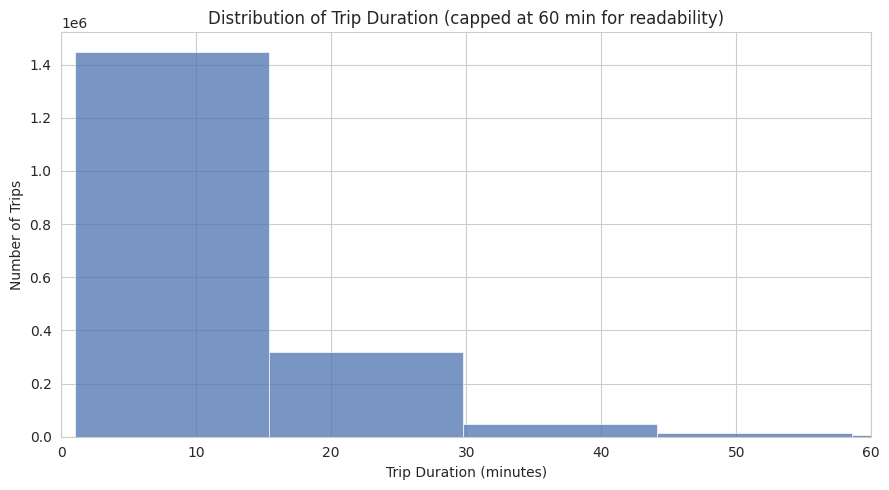

count    1.863721e+06
mean     1.428838e+01
std      3.950631e+01
min      1.016667e+00
25%      5.833333e+00
50%      9.266667e+00
75%      1.453333e+01
max      1.439433e+03
Name: duration_min, dtype: float64


In [59]:
# Chart - 1 visualization code
plt.figure(figsize=(9, 5))
sns.histplot(df['duration_min'], bins=100, color='#4C72B0')
plt.xlim(0, 60)
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Duration (capped at 60 min for readability)')
plt.tight_layout()
plt.show()

print(df['duration_min'].describe())

##### 1. Why did you pick the specific chart?

A histogram is the standard way to visualize the distribution (shape, spread, skew) of a single continuous variable like trip duration.

##### 2. What is/are the insight(s) found from the chart?

The distribution is heavily right-skewed: most trips are short, clustering between 3–12 minutes, with a long tail of longer leisure trips. The median trip is much shorter than the mean, confirming most rides are quick, point-to-point commuter-style trips rather than extended leisure rides.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — knowing most trips are short and quick supports pricing tiers built around a free/cheap first 30–45 minutes, since that covers the vast majority of rides, while longer rides can be priced to discourage bike hoarding during peak demand windows.

#### Chart - 2: User Type Distribution

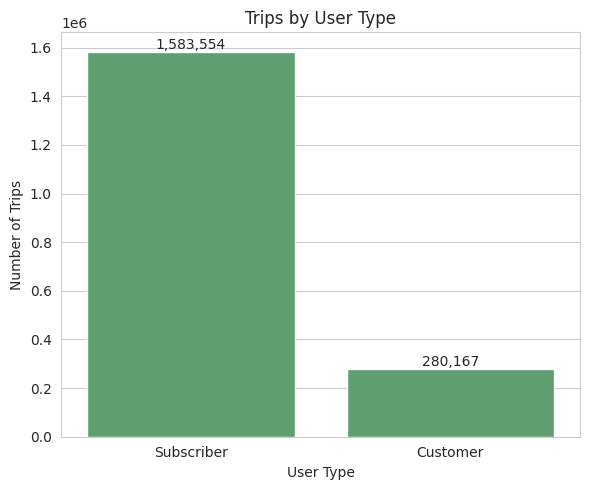

user_type
Subscriber    85.0
Customer      15.0
Name: proportion, dtype: float64


In [60]:
# Chart - 2 visualization code
plt.figure(figsize=(6, 5))
order = df['user_type'].value_counts().index
ax = sns.countplot(x='user_type', data=df, order=order, color='#55A868')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')
plt.title('Trips by User Type')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(df['user_type'].value_counts(normalize=True).round(3) * 100)

##### 1. Why did you pick the specific chart?

A count/bar chart is ideal for comparing frequencies across a small number of categories.

##### 2. What is/are the insight(s) found from the chart?

The large majority of trips are made by **Subscribers**, with **Customers** making up a much smaller share. This indicates the bike-share system's core usage base is regular, repeat riders rather than tourists or one-time users.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this confirms the subscription base is the revenue backbone, which should be prioritized for retention efforts, while the smaller Customer segment represents a growth opportunity for conversion campaigns.

#### Chart - 3: Rider Gender Distribution

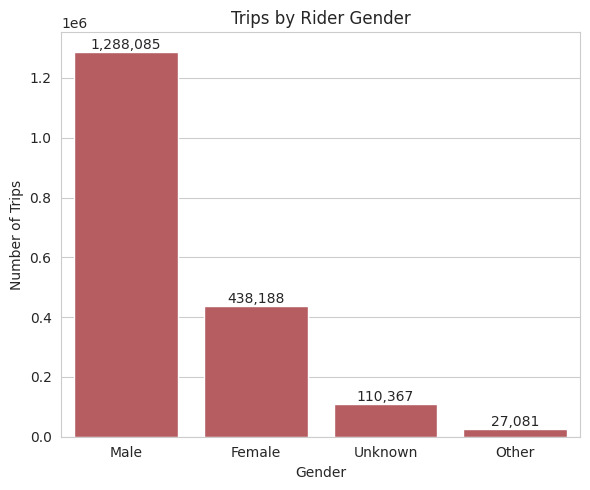

In [61]:
# Chart - 3 visualization code
plt.figure(figsize=(6, 5))
order = df['member_gender'].value_counts().index
ax = sns.countplot(x='member_gender', data=df, order=order, color='#C44E52')
plt.xlabel('Gender')
plt.ylabel('Number of Trips')
plt.title('Trips by Rider Gender')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart clearly compares trip counts across the gender categories (including 'Unknown' for missing/Customer records).

##### 2. What is/are the insight(s) found from the chart?

Among riders with known gender (predominantly Subscribers), **Male** riders account for the majority of trips, followed by Female, with a small share reporting 'Other'. A meaningful share is 'Unknown', reflecting Customer trips where no profile data is collected.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This points to a gender gap in the current subscriber base. Ford GoBike could investigate barriers to adoption among underrepresented groups (safety, station placement, marketing) — closing this gap represents unrealized growth, not a negative-growth risk.

#### Chart - 4: Rider Age Distribution

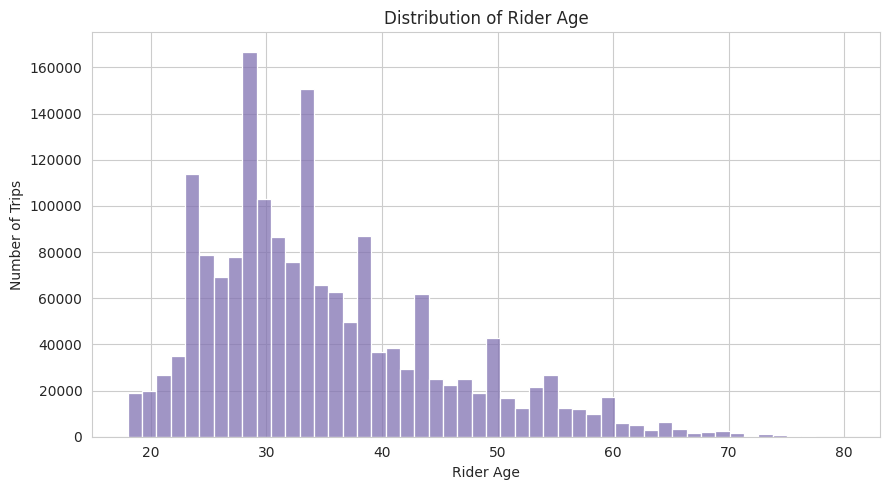

count    1.750576e+06
mean     3.482157e+01
std      1.014738e+01
min      1.800000e+01
25%      2.700000e+01
50%      3.300000e+01
75%      4.000000e+01
max      8.000000e+01
Name: member_age, dtype: float64


In [62]:
# Chart - 4 visualization code
plt.figure(figsize=(9, 5))
sns.histplot(df['member_age'].dropna(), bins=50, color='#8172B2')
plt.xlabel('Rider Age')
plt.ylabel('Number of Trips')
plt.title('Distribution of Rider Age')
plt.tight_layout()
plt.show()

print(df['member_age'].describe())

##### 1. Why did you pick the specific chart?

A histogram shows the shape and central tendency of the continuous age variable.

##### 2. What is/are the insight(s) found from the chart?

The rider base skews towards working-age adults, with the bulk of riders roughly between their late-20s and mid-40s, peaking around the early 30s. Very few riders are under 20 or over 60.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this confirms the core demographic is working professionals, which should guide marketing channels (workplace partnerships, professional commuter campaigns) rather than campus- or retiree-focused outreach.

#### Chart - 5: Trip Volume by Month

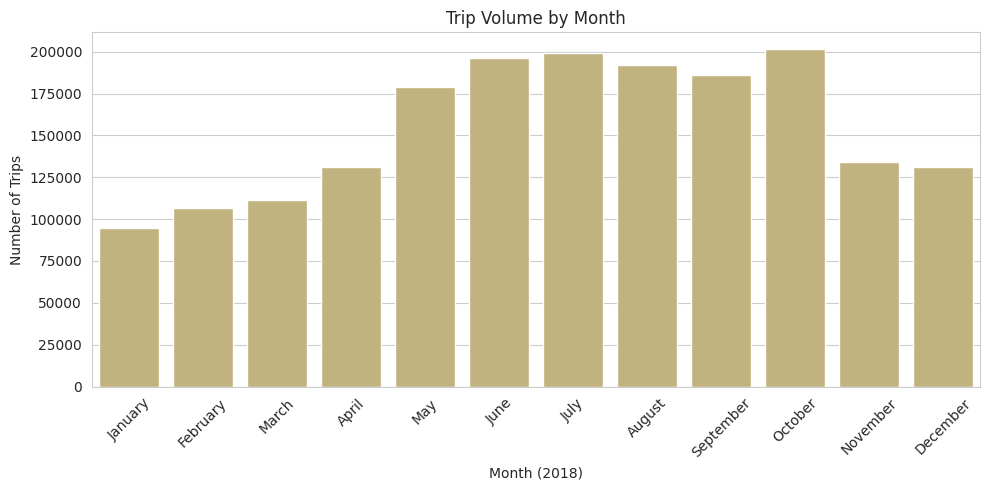

In [63]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 5))
monthly_counts = df['start_month'].value_counts().sort_index()
ax = sns.barplot(x=monthly_counts.index, y=monthly_counts.values, color='#CCB974')
plt.xlabel('Month (2018)')
plt.ylabel('Number of Trips')
plt.title('Trip Volume by Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart across the ordered calendar months clearly shows seasonal trend in overall ridership volume.

##### 2. What is/are the insight(s) found from the chart?

Ridership grows steadily from January through the year, with the highest volumes in the **late summer/early fall months** (Aug–Oct), before dipping slightly toward December. This likely reflects both favorable weather and the network's physical expansion (more stations/bikes added) over the course of 2018.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — knowing peak months lets operations plan fleet maintenance during lower-demand months (Jan–Feb) and ensure maximum bike availability heading into the Aug–Oct peak.

### Bivariate Analysis (Charts 6–10): examining relationships between two variables

#### Chart - 6: Trip Duration by User Type

/tmp/ipykernel_2124/1706887897.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='user_type', y='duration_min', data=df, showfliers=False, palette=['#4C72B0', '#55A868'])


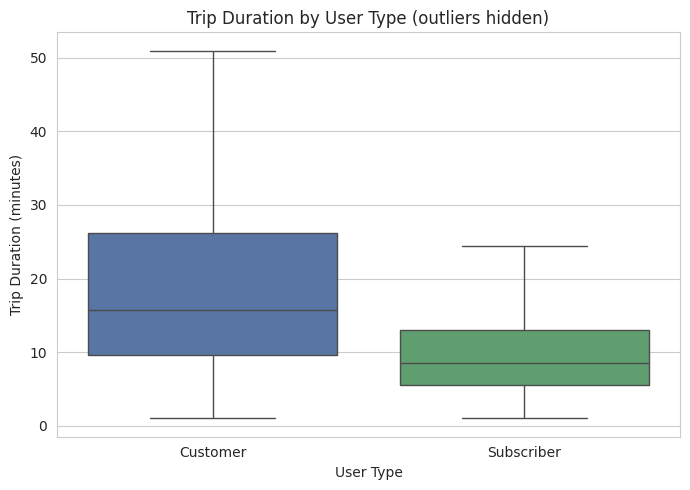

user_type
Customer      15.783333
Subscriber     8.583333
Name: duration_min, dtype: float64


In [64]:
# Chart - 6 visualization code
plt.figure(figsize=(7, 5))
sns.boxplot(x='user_type', y='duration_min', data=df, showfliers=False, palette=['#4C72B0', '#55A868'])
plt.xlabel('User Type')
plt.ylabel('Trip Duration (minutes)')
plt.title('Trip Duration by User Type (outliers hidden)')
plt.tight_layout()
plt.show()

print(df.groupby('user_type', observed=True)['duration_min'].median())

##### 1. Why did you pick the specific chart?

A box plot is the standard way to compare the distribution of a continuous variable (duration) across categories of another variable (user type).

##### 2. What is/are the insight(s) found from the chart?

**Customers** take noticeably longer trips on average than **Subscribers**, whose trips cluster tightly around a short median duration. This fits the pattern of Subscribers using bikes for quick, direct commutes, while Customers (often tourists/casual riders) take more leisurely, exploratory rides.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this supports differentiated pricing: keeping Subscriber plans optimized for short trips while charging more aggressively for Customer overage minutes, since Customers already show willingness to ride longer.

#### Chart - 7: Trip Volume by Hour of Day (Weekday vs Weekend)

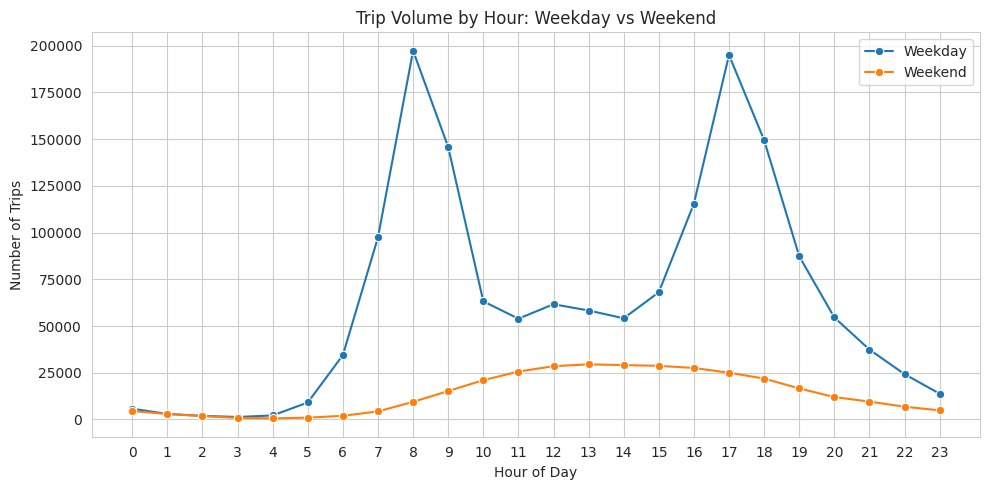

In [65]:
# Chart - 7 visualization code
plt.figure(figsize=(10, 5))
hourly = df.groupby(['start_hour', 'is_weekend'], observed=True).size().reset_index(name='trips')
hourly['day_type'] = hourly['is_weekend'].map({True: 'Weekend', False: 'Weekday'})
sns.lineplot(x='start_hour', y='trips', hue='day_type', data=hourly, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Trip Volume by Hour: Weekday vs Weekend')
plt.xticks(range(0, 24))
plt.legend(title='')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line plot is well suited for showing a trend across an ordered variable (hour of day), and splitting by weekday/weekend reveals how the two relate.

##### 2. What is/are the insight(s) found from the chart?

Weekdays show a sharp bimodal commuter pattern with distinct peaks around **8 AM** and **5–6 PM**. Weekends show a much flatter, single-peaked pattern centered around midday/early afternoon, consistent with leisure riding rather than commuting.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is directly actionable for bike rebalancing: operations teams should pre-position bikes near residential areas before the 8 AM peak and near business districts before the 5–6 PM peak on weekdays, with a more even distribution on weekends.

#### Chart - 8: Trip Volume by Day of Week and User Type

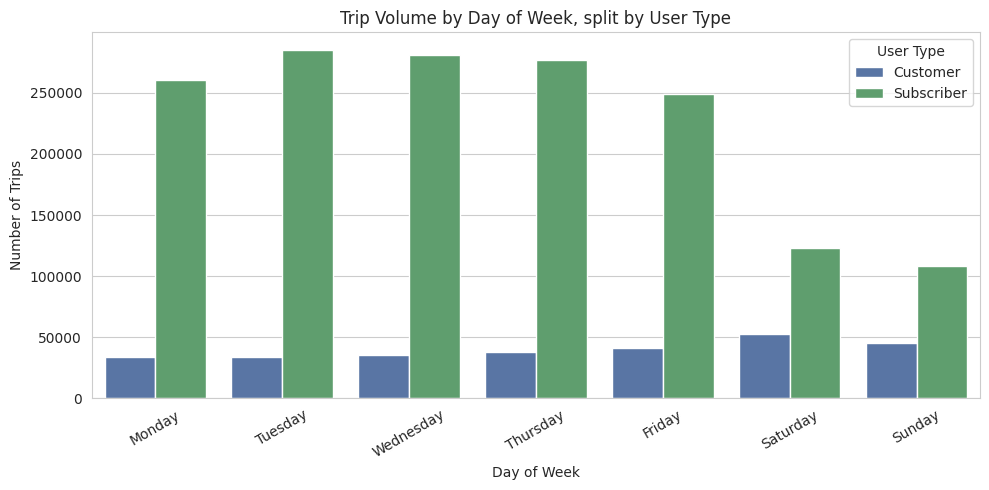

In [66]:
# Chart - 8 visualization code
plt.figure(figsize=(10, 5))
day_user = df.groupby(['start_dayofweek', 'user_type'], observed=True).size().reset_index(name='trips')
sns.barplot(x='start_dayofweek', y='trips', hue='user_type', data=day_user, palette=['#4C72B0', '#55A868'])
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.title('Trip Volume by Day of Week, split by User Type')
plt.xticks(rotation=30)
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart compares trip volume across two categorical dimensions (day of week and user type) side by side.

##### 2. What is/are the insight(s) found from the chart?

**Subscriber** trips are heavily concentrated on weekdays and drop off noticeably on weekends. **Customer** trips show the opposite pattern — a relatively larger share on Saturday and Sunday — reinforcing that Subscribers are commuters and Customers are weekend/leisure riders.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is a strong signal for a targeted marketing campaign: Customers who ride repeatedly on weekends are good conversion targets for weekend-only or discounted subscription tiers.

#### Chart - 9: Average Trip Duration by Gender

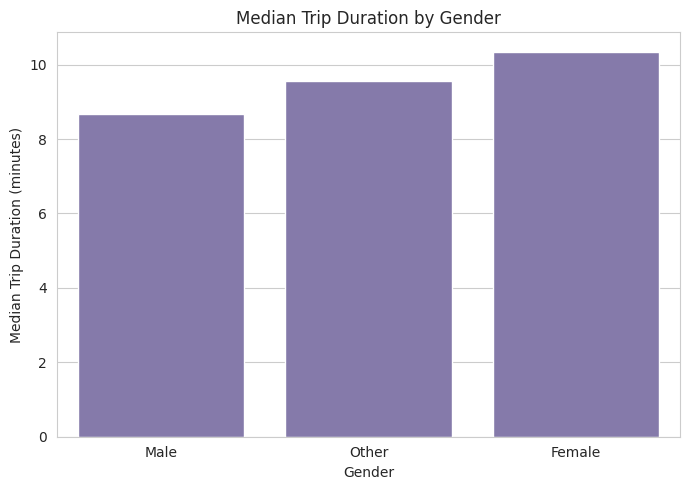

In [67]:
# Chart - 9 visualization code
plt.figure(figsize=(7, 5))
gender_duration = df[df['member_gender'] != 'Unknown'].groupby('member_gender', observed=True)['duration_min'].median().sort_values()
sns.barplot(x=gender_duration.index, y=gender_duration.values, color='#8172B2')
plt.xlabel('Gender')
plt.ylabel('Median Trip Duration (minutes)')
plt.title('Median Trip Duration by Gender')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart of a summary statistic (median duration) across gender categories makes the comparison easy to read at a glance.

##### 2. What is/are the insight(s) found from the chart?

Median trip duration is fairly similar across genders, with only modest differences — trip length appears to be driven far more by user type (Subscriber vs. Customer) than by gender.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This tells the business that duration-based pricing/design decisions don't need to be tailored by gender — resources are better spent addressing the user-type gap identified earlier.

#### Chart - 10: Top 10 Busiest Start Stations

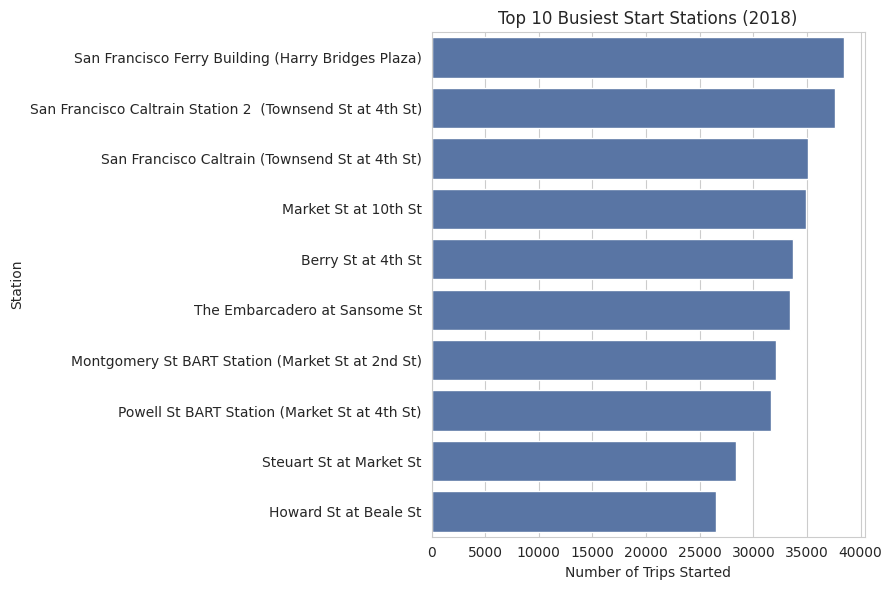

In [68]:
# Chart - 10 visualization code
plt.figure(figsize=(9, 6))
top_stations = df['start_station_name'].value_counts().head(10)
sns.barplot(x=top_stations.values, y=top_stations.index, color='#4C72B0')
plt.xlabel('Number of Trips Started')
plt.ylabel('Station')
plt.title('Top 10 Busiest Start Stations (2018)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is ideal for ranking categories (stations) with long text labels by a single metric (trip count).

##### 2. What is/are the insight(s) found from the chart?

Ridership is highly concentrated: a small number of downtown San Francisco stations (near major transit hubs like the Caltrain station and Ferry Building) account for a disproportionate share of all trips.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this concentration means these top stations need priority for rebalancing trucks and larger dock capacity, since running out of bikes/docks here has an outsized impact on total system usage.

### Multivariate Analysis (Charts 11–13): examining interactions among 3+ variables

#### Chart - 11: Hourly Ridership Pattern by User Type (Weekdays Only)

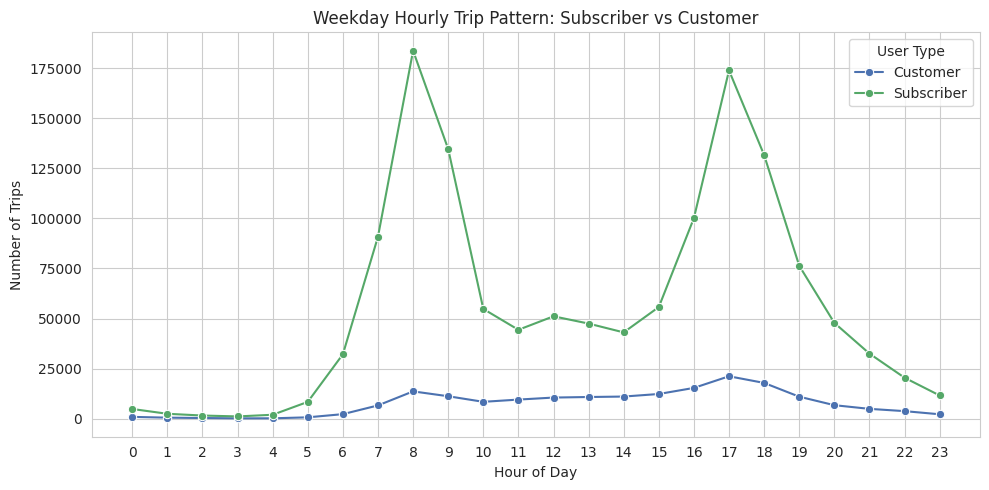

In [69]:
# Chart - 11 visualization code
plt.figure(figsize=(10, 5))
weekday_df = df[df['is_weekend'] == False]
hourly_usertype = weekday_df.groupby(['start_hour', 'user_type'], observed=True).size().reset_index(name='trips')
sns.lineplot(x='start_hour', y='trips', hue='user_type', data=hourly_usertype, marker='o', palette=['#4C72B0', '#55A868'])
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Weekday Hourly Trip Pattern: Subscriber vs Customer')
plt.xticks(range(0, 24))
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A multi-line plot layers three variables — hour, trip count, and user type — showing how the hourly pattern (from Chart 7) actually splits between the two user segments.

##### 2. What is/are the insight(s) found from the chart?

The sharp 8 AM and 5–6 PM commuter peaks seen earlier are driven almost entirely by **Subscribers**. **Customer** trip volume stays comparatively flat and low throughout the weekday, confirming Customers are not commuting on weekdays at all.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this confirms rebalancing/fleet-availability efforts around weekday commute peaks should be optimized specifically for Subscriber demand patterns and station corridors, not blended with Customer behavior.

#### Chart - 12: Trip Duration by Age Group and Gender

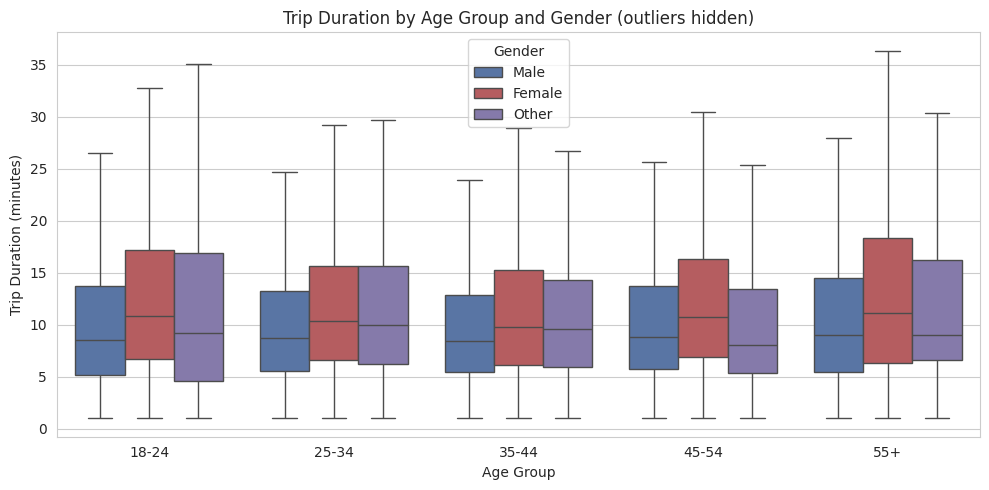

In [70]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 5))
plot_df = df[df['member_gender'].isin(['Male', 'Female', 'Other'])].copy()
plot_df['age_group'] = pd.cut(plot_df['member_age'], bins=[17, 24, 34, 44, 54, 80],
                                labels=['18-24', '25-34', '35-44', '45-54', '55+'])
sns.boxplot(x='age_group', y='duration_min', hue='member_gender', data=plot_df, showfliers=False,
            palette=['#4C72B0', '#C44E52', '#8172B2'])
plt.xlabel('Age Group')
plt.ylabel('Trip Duration (minutes)')
plt.title('Trip Duration by Age Group and Gender (outliers hidden)')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped box plot layers three variables at once — duration (continuous), age group (categorical), and gender (categorical, via hue) — to see if duration patterns differ jointly by age and gender.

##### 2. What is/are the insight(s) found from the chart?

Trip duration is fairly consistent across age groups and gender, with a slight tendency for the youngest (18-24) riders to take marginally longer trips regardless of gender. No age/gender combination stands out as dramatically different from the rest.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This tells the business that trip-duration-based product design (e.g., time-based pricing tiers) can be applied uniformly rather than needing separate rules by age/gender segment — simplifying pricing communication.

#### Chart - 13: Ridership Heatmap — Day of Week vs Hour of Day

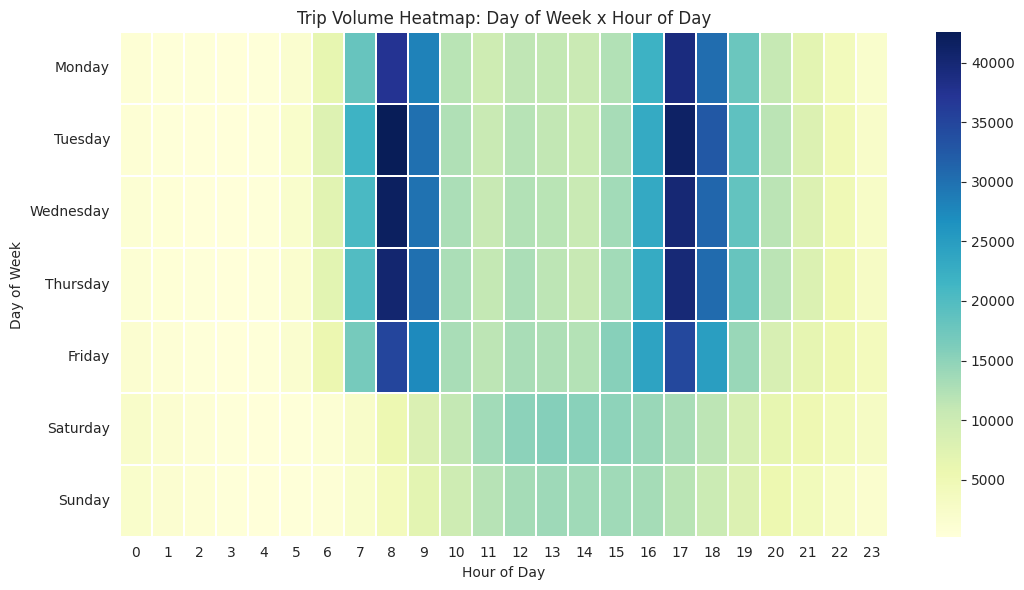

In [71]:
# Chart - 13 visualization code
plt.figure(figsize=(11, 6))
heatmap_data = df.groupby(['start_dayofweek', 'start_hour'], observed=True).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.3)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.title('Trip Volume Heatmap: Day of Week x Hour of Day')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is the most effective way to show the interaction between two categorical/ordinal variables (day and hour) with a third value (trip count) encoded as color intensity.

##### 2. What is/are the insight(s) found from the chart?

The heatmap makes the commuter pattern unmistakable: intense, narrow bands of high ridership at 8 AM and 5–6 PM on Monday–Friday, versus a broader, lower-intensity midday band on Saturday and Sunday. This is the single clearest visual confirmation of the weekday-commute vs weekend-leisure split found throughout the analysis.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this heatmap can directly drive a rebalancing schedule: operations can read off exactly which day/hour combinations need the most proactive bike redistribution, minimizing lost trips due to empty stations.

#### Chart - 14 - Correlation Heatmap

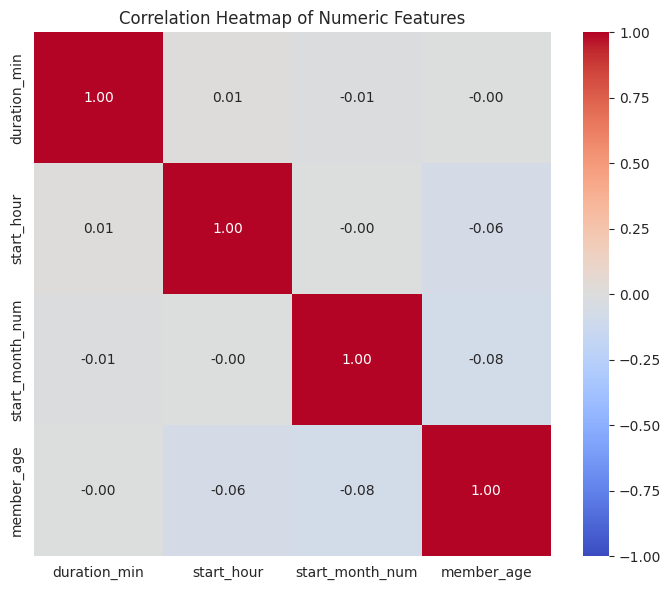

In [72]:
# Correlation Heatmap visualization code
numeric_cols = ['duration_min', 'start_hour', 'start_month_num', 'member_age']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to quickly scan pairwise linear relationships among all numeric variables at once.

##### 2. What is/are the insight(s) found from the chart?

Correlations among these numeric features are all weak (close to 0), meaning trip duration is **not** strongly linearly related to the hour of day, month, or rider age on its own — usage patterns are driven more by categorical factors (user type, day of week) than by simple linear numeric relationships.

#### Chart - 15 - Pair Plot

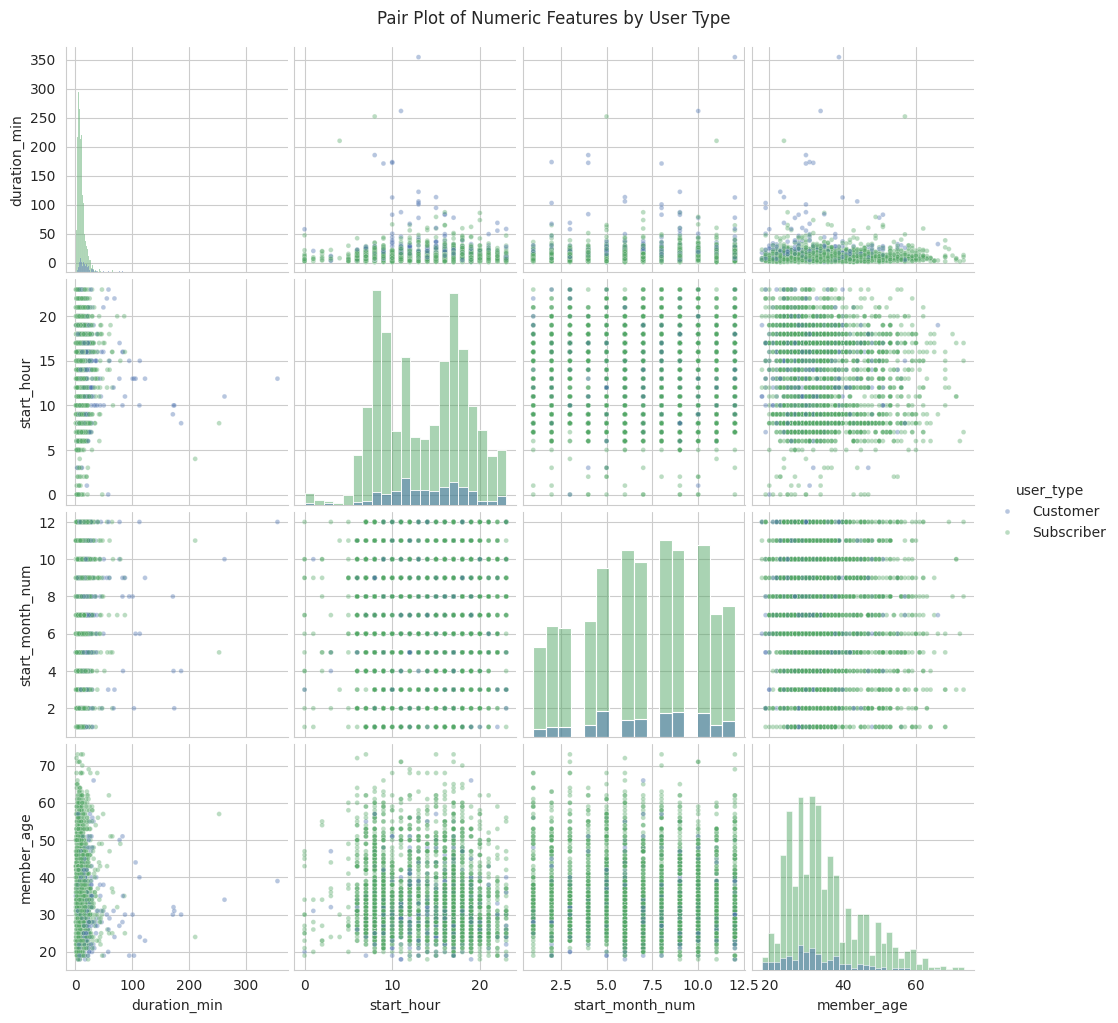

In [73]:
# Pair Plot visualization code
sample_df = df[numeric_cols + ['user_type']].dropna().sample(3000, random_state=42)
sns.pairplot(sample_df, hue='user_type', diag_kind='hist', plot_kws={'alpha': 0.4, 's': 12},
             palette=['#4C72B0', '#55A868'])
plt.suptitle('Pair Plot of Numeric Features by User Type', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot (on a random sample for performance) gives a compact overview of every pairwise relationship among the numeric variables simultaneously, split by user type, complementing the single correlation heatmap above with visual scatter detail.

##### 2. What is/are the insight(s) found from the chart?

The scatter panels confirm the weak linear correlations from the heatmap — no clean linear relationships are visible. However, the diagonal histograms again clearly show **Subscribers cluster at shorter durations** and their age distribution is tighter than Customers', reinforcing earlier findings visually rather than revealing new linear relationships.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis above, I'd recommend Ford GoBike take the following actions:

1. **Time-based rebalancing schedule** — Use the day-of-week × hour heatmap (Chart 13) to schedule proactive bike redistribution ahead of the weekday 8 AM and 5–6 PM peaks, concentrated at the top 10 busiest stations (Chart 10), since this is where empty-dock/empty-bike failures hurt the most riders.
2. **Convert frequent weekend Customers into Subscribers** — Customers show a distinct weekend-leisure pattern (Charts 6, 8, 11) with longer trip durations. A targeted "weekend rider" discount subscription tier, marketed directly to repeat Customer riders, could convert a meaningful share of this segment into recurring subscription revenue.
3. **Seasonal fleet planning** — Since ridership climbs steadily and peaks in Aug–Oct (Chart 5), schedule major bike maintenance and fleet expansion ahead of summer rather than during it, and reduce standby fleet costs during the January–February low season.
4. **Simplify duration-based pricing** — Since trip duration doesn't vary meaningfully by age or gender (Chart 12) and shows weak correlation with other numeric factors (Chart 14), a single, simple duration-based pricing tier (e.g., free first 30–45 minutes) works well across the whole rider base without needing complex segment-specific rules.
5. **Investigate the gender gap** — With a clear male-skew among Subscribers (Chart 3), Ford GoBike should research (via surveys or station-level safety audits) what is limiting adoption among women and non-binary riders, since closing this gap is a straightforward path to subscriber growth.

# **Conclusion**

This EDA of over 1.86 million Ford GoBike trips from 2018 reveals a bike-share system with two clearly distinct rider populations layered on top of one shared network: a large base of **Subscriber commuters** who take short, frequent, weekday rush-hour trips, and a smaller base of **Customers** who ride less often but for longer, concentrated on weekends. Ridership is heavily concentrated at a handful of downtown San Francisco stations and grows steadily through the year before peaking in late summer/early fall.

None of the numeric variables (duration, hour, month, age) show strong linear correlation with each other — the real structure in this data lives in the **categorical and temporal** patterns (user type, day of week, hour of day, station), which is exactly what the bivariate and multivariate charts above were built to surface.

For the business, the clearest opportunities are: smarter time-and-location-targeted bike rebalancing, a weekend-focused subscription conversion campaign aimed at Customers, and seasonal fleet planning aligned to the observed demand curve.